#**Etude cas 2 :** Données réelles

# **Simulation du modèle :**

In [ ]:
install.packages("deSolve")
library(deSolve)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



     [,1] [,2] [,3] [,4]
[1,]  1.5  0.8  0.3  0.1
[2,]  0.8  1.2  0.5  0.1
[3,]  0.3  0.5  0.7  0.2
[4,]  0.1  0.1  0.2  0.4
Infectés initiaux :
[1] 8 3 3 1
Susceptibles initiaux :
[1] 19497 14799 24998  9999
  time       S1       S2       S3       S4        I1       I2       I3       I4
1    0 19497.00 14799.00 24998.00 9999.000  8.000000 3.000000 3.000000 1.000000
2    1 19495.63 14798.18 24997.29 9998.894  8.948914 3.653049 3.545167 1.055061
3    2 19494.06 14797.23 24996.47 9998.774 10.039861 4.402269 4.174842 1.120748
4    3 19492.28 14796.13 24995.52 9998.638 11.294020 5.262059 4.901669 1.198618
5    4 19490.23 14794.86 24994.41 9998.484 12.735726 6.248961 5.740178 1.290461
6    5 19487.90 14793.38 24993.13 9998.309 14.392929 7.381975 6.707066 1.398336
         R1        R2        R3         R4          PI1          PI2
1 0.0000000 0.0000000 0.0000000 0.00000000 0.0004101512 0.0002026753
2 0.4231716 0.1659531 0.1633013 0.05133523 0.0004588010 0.0002467943
3 0.8972574 0.3669069 0.

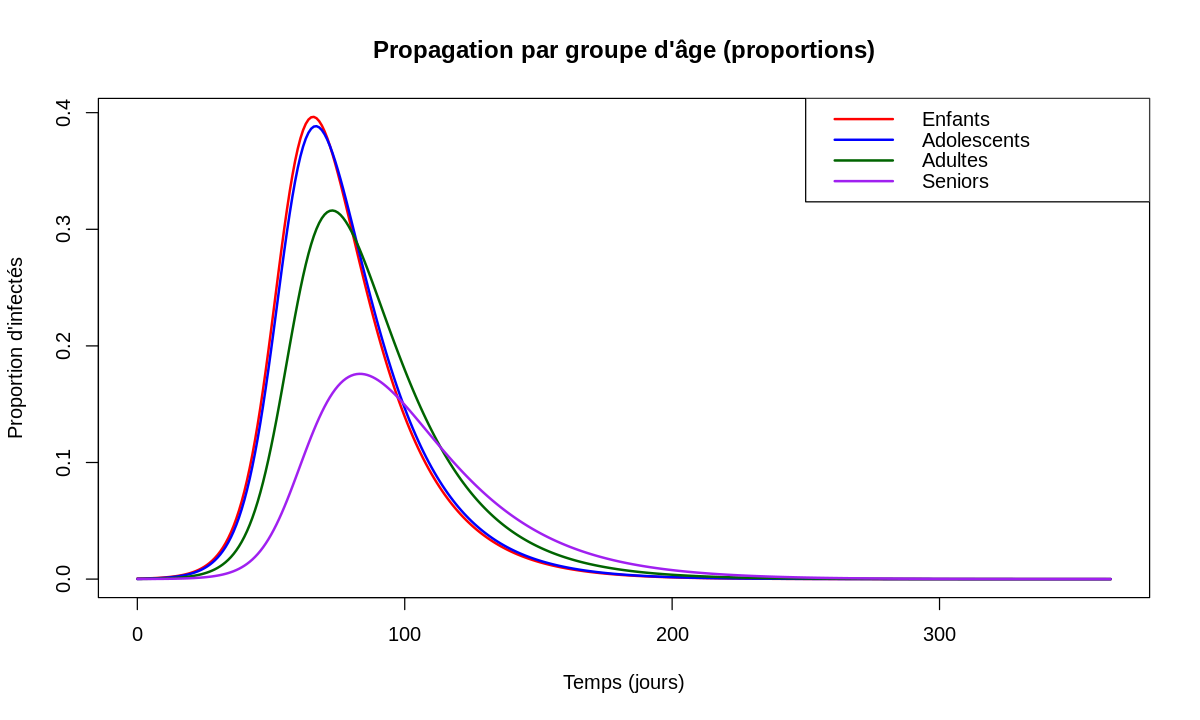

In [ ]:
# ==================================================
# GROUPES D'AGE

# ==================================================

groupes = c(
  "Enfants",
  "Adolescents",
  "Adultes",
  "Seniors"
)

# ==================================================
# MATRICE WAIFW
# ==================================================

W = matrix(
  c(
    1.5, 0.8, 0.3, 0.1,
    0.8, 1.2, 0.5, 0.1,
    0.3, 0.5, 0.7, 0.2,
    0.1, 0.1, 0.2, 0.4
  ),
  nrow = 4,
  byrow = TRUE
)

print(W)

# ==================================================
# PARAMETRES "VRAIS"
# ==================================================

beta  = 0.08
gamma = 0.05

FE = 0.0001

N0 = c(
  19505,
  14802,
  25001,
  10000
)

# ==================================================

# TEMPS
# ==================================================

temps = seq(0, 364, by = 1)

# ==================================================
# MODELE SIR STRUCTURE PAR AGE
# ==================================================

modele_age <- function(temps, etat, parametres){

  S = etat[1:4]
  I = etat[5:8]
  R = etat[9:12]

  beta  = parametres["beta"]
  gamma = parametres["gamma"]

  N = S + I + R

  lambda = numeric(4)

  for(i in 1:4){
    lambda[i] = beta * sum(W[i, ] * (I / N))
  }

  dS = -lambda * S
  dI = lambda * S - gamma * I
  dR = gamma * I

  list(c(dS, dI, dR))
}

# ==================================================
# SIMULATION
# ==================================================

simuler_age <- function(beta, gamma, FE, N0){

  risque = c(4, 2, 1, 1)

  I0 = round(FE * N0 * risque)
  S0 = N0 - I0
  R0 = rep(0, 4)

  cat("Infectés initiaux :\n")
  print(I0)

  cat("Susceptibles initiaux :\n")
  print(S0)

  etat_initial = c(S0, I0, R0)

  parametres = c(beta = beta, gamma = gamma)

  resultat = ode(
    y = etat_initial,
    times = temps,
    func = modele_age,
    parms = parametres
  )

  resultat = as.data.frame(resultat)

  colnames(resultat) = c(
    "time",
    "S1","S2","S3","S4",
    "I1","I2","I3","I4",
    "R1","R2","R3","R4"
  )

  # ==================================================
  # PROPORTIONS D'INFECTÉS
  # ==================================================

  N1 = resultat$S1 + resultat$I1 + resultat$R1
  N2 = resultat$S2 + resultat$I2 + resultat$R2
  N3 = resultat$S3 + resultat$I3 + resultat$R3
  N4 = resultat$S4 + resultat$I4 + resultat$R4

  resultat$PI1 = resultat$I1 / N1
  resultat$PI2 = resultat$I2 / N2
  resultat$PI3 = resultat$I3 / N3
  resultat$PI4 = resultat$I4 / N4

  return(resultat)
}

# ==================================================
# SIMULATION
# ==================================================

D = simuler_age(
  beta = beta,
  gamma = gamma,
  FE = FE,
  N0 = N0
)

print(head(D))
print(tail(D))

# ==================================================
# GRAPHIQUE UNIQUE
# ==================================================

options(
  repr.plot.width = 10,
  repr.plot.height = 6
)

plot(
  D$time,
  D$PI1,
  type = "l",
  col = "red",
  lwd = 2,
  ylim = c(0, max(D$PI1, D$PI2, D$PI3, D$PI4)),
  xlab = "Temps (jours)",
  ylab = "Proportion d'infectés",
  main = "Propagation par groupe d'âge (proportions)"
)

lines(D$time, D$PI2, col = "blue", lwd = 2)
lines(D$time, D$PI3, col = "darkgreen", lwd = 2)
lines(D$time, D$PI4, col = "purple", lwd = 2)

legend(
  "topright",
  legend = c("Enfants", "Adolescents", "Adultes", "Seniors"),
  col = c("red", "blue", "darkgreen", "purple"),
  lwd = 2
)

# **Simulation ABC**

# **ABC-Rejet :**

**Calcul de la distance qui sera utilisé dans l'ABC-Rejet**

In [ ]:
calc_distance = function( D , D_star ){

  S_total_star = D_star$S1 + D_star$S2 + D_star$S3 + D_star$S4
  S_total = D$S1 + D$S2 + D$S3 + D$S4

  new_cases_star = c(0, -diff(S_total_star))
  new_cases = c(0, -diff(S_total))

  n_week <- floor(nrow(D)/7)

  simul_week = numeric(n_week)
  obs_week = numeric(n_week)


  for(i in 1:n_week){

  debut <- (i-1)*7 + 1
  fin   <- i*7

  simul_week[i] <- sum(new_cases_star[debut:fin])
  obs_week[i]   <- sum(new_cases[debut:fin])
}

  dist_T = sqrt( sum((obs_week - simul_week )^2) )

  # pour la distance p/r  l'age
  #on cherche le max dans chque groupes pour avoir le nb total de personnes infecté dans chaque groupe
  simul_age = c(max(D_star$R1),max(D_star$R2),max(D_star$R3),max(D_star$R4))
  # on transforme ca sous forme de proportion
  simul_age = simul_age/sum(simul_age)
  # On suppose que c'est la proportion des malades chez les groupes
obs_age <- c(
  tail(D$R1,1),
  tail(D$R2,1),
  tail(D$R3,1),
  tail(D$R4,1)
)

D_obs_age <- obs_age / sum(obs_age)
dist_A = sqrt( sum((simul_age - D_obs_age )^2))

  return(c(dist_T, dist_A))
}

**Simulation de ABC-Rejet dans le cas de la comparaison avec l'ABC-SMC. Les tolérances de l'ABC-Rejet correspond aux dernières tolérances de l'ABC-SMC**

In [ ]:
D = simuler_age( beta  = 0.08 , gamma = 0.05 , FE = 0.0001 , N0 = c(19505,14802,25001,10000) )
N_particule <- 10  # Nb de particules acceptées (ce choix permet de faire tourner plus rapidement le code mais l'estimation est moins précise)

epsilon_T <- 3000
epsilon_A <- 0.02



res<-matrix(ncol=6,nrow=N_particule)


i <- 1  # compteur initiale pour les particules acceptées
j <- 1  # compteur initiale pour les particules prooposées

while(i <= N_particule){ # tant que le nb de particules acceptées est inférieur à N_particule

    # Sample from prior distributions
    N0_total <- runif(1, min=50000, max=150000)
    prop_age <- c(0.2814265,0.2135655,0.3607184,0.1442896)  #nb de personne dans chaque groupe diviser par le nb total de personne
    N0_star <- round(N0_total * prop_age)
	  f_E_star<-runif(1, min=0, max=0.001)
	  gamma_star <-runif(1, min=0.01, max=0.2)
	  beta_star<- runif(1, min=0.01, max=0.2)

    # Simulation du jeu de donnée
    D_star<-simuler_age( beta_star, gamma_star , f_E_star, N0_star)

    # Calcul de la distance
    distance = calc_distance(D,D_star)

    if((distance[1] <= epsilon_T) & (distance[2] <= epsilon_A)){ # Si les deux distances sont inférieures à leurs tolérances
      # on garde les données
      res[i,]<-c(beta_star, gamma_star , f_E_star, N0_total,distance[1],distance[2])
      i <- i + 1  # mise à jour du compteur
    }
	  j <- j + 1 # mise à jour du compteur
	  acc_rate <- i / j # Calcul du taux d'acceptation
	  cat("current acceptance rate = ", round(acc_rate, 5), "\n")
}

# Convert res to a data frame and name columns for easier access in plotting
res <- as.data.frame(res)
colnames(res) <- c("beta_star", "gamma_star", "f_E_star", "N0_total", "dist_T", "dist_A")

**On simule le code du dessus 5 fois et à la fin on les met ensemble avec la fonction ci-dessous et le all_lists garde la même structure que les autres all_res**
- all_lists <- rbin(all_res,all_res_1, all_res_2, all_res_3,all_res_4)

**On télécharge ces données en gardant la même structure en utilisant**
- saveRDS(all_lists, file = "/content/all_lists_structure.rds")

**Et lorsqu'on veut utiliser ce tableau, on le met dans l'environnement Google Collab et on utilise cette formule pour récuperer ces données**
- res <- readRDS("/content/res.rds")

In [ ]:
#Ce fichier est dans le github
res = readRDS("/content/res.rds")


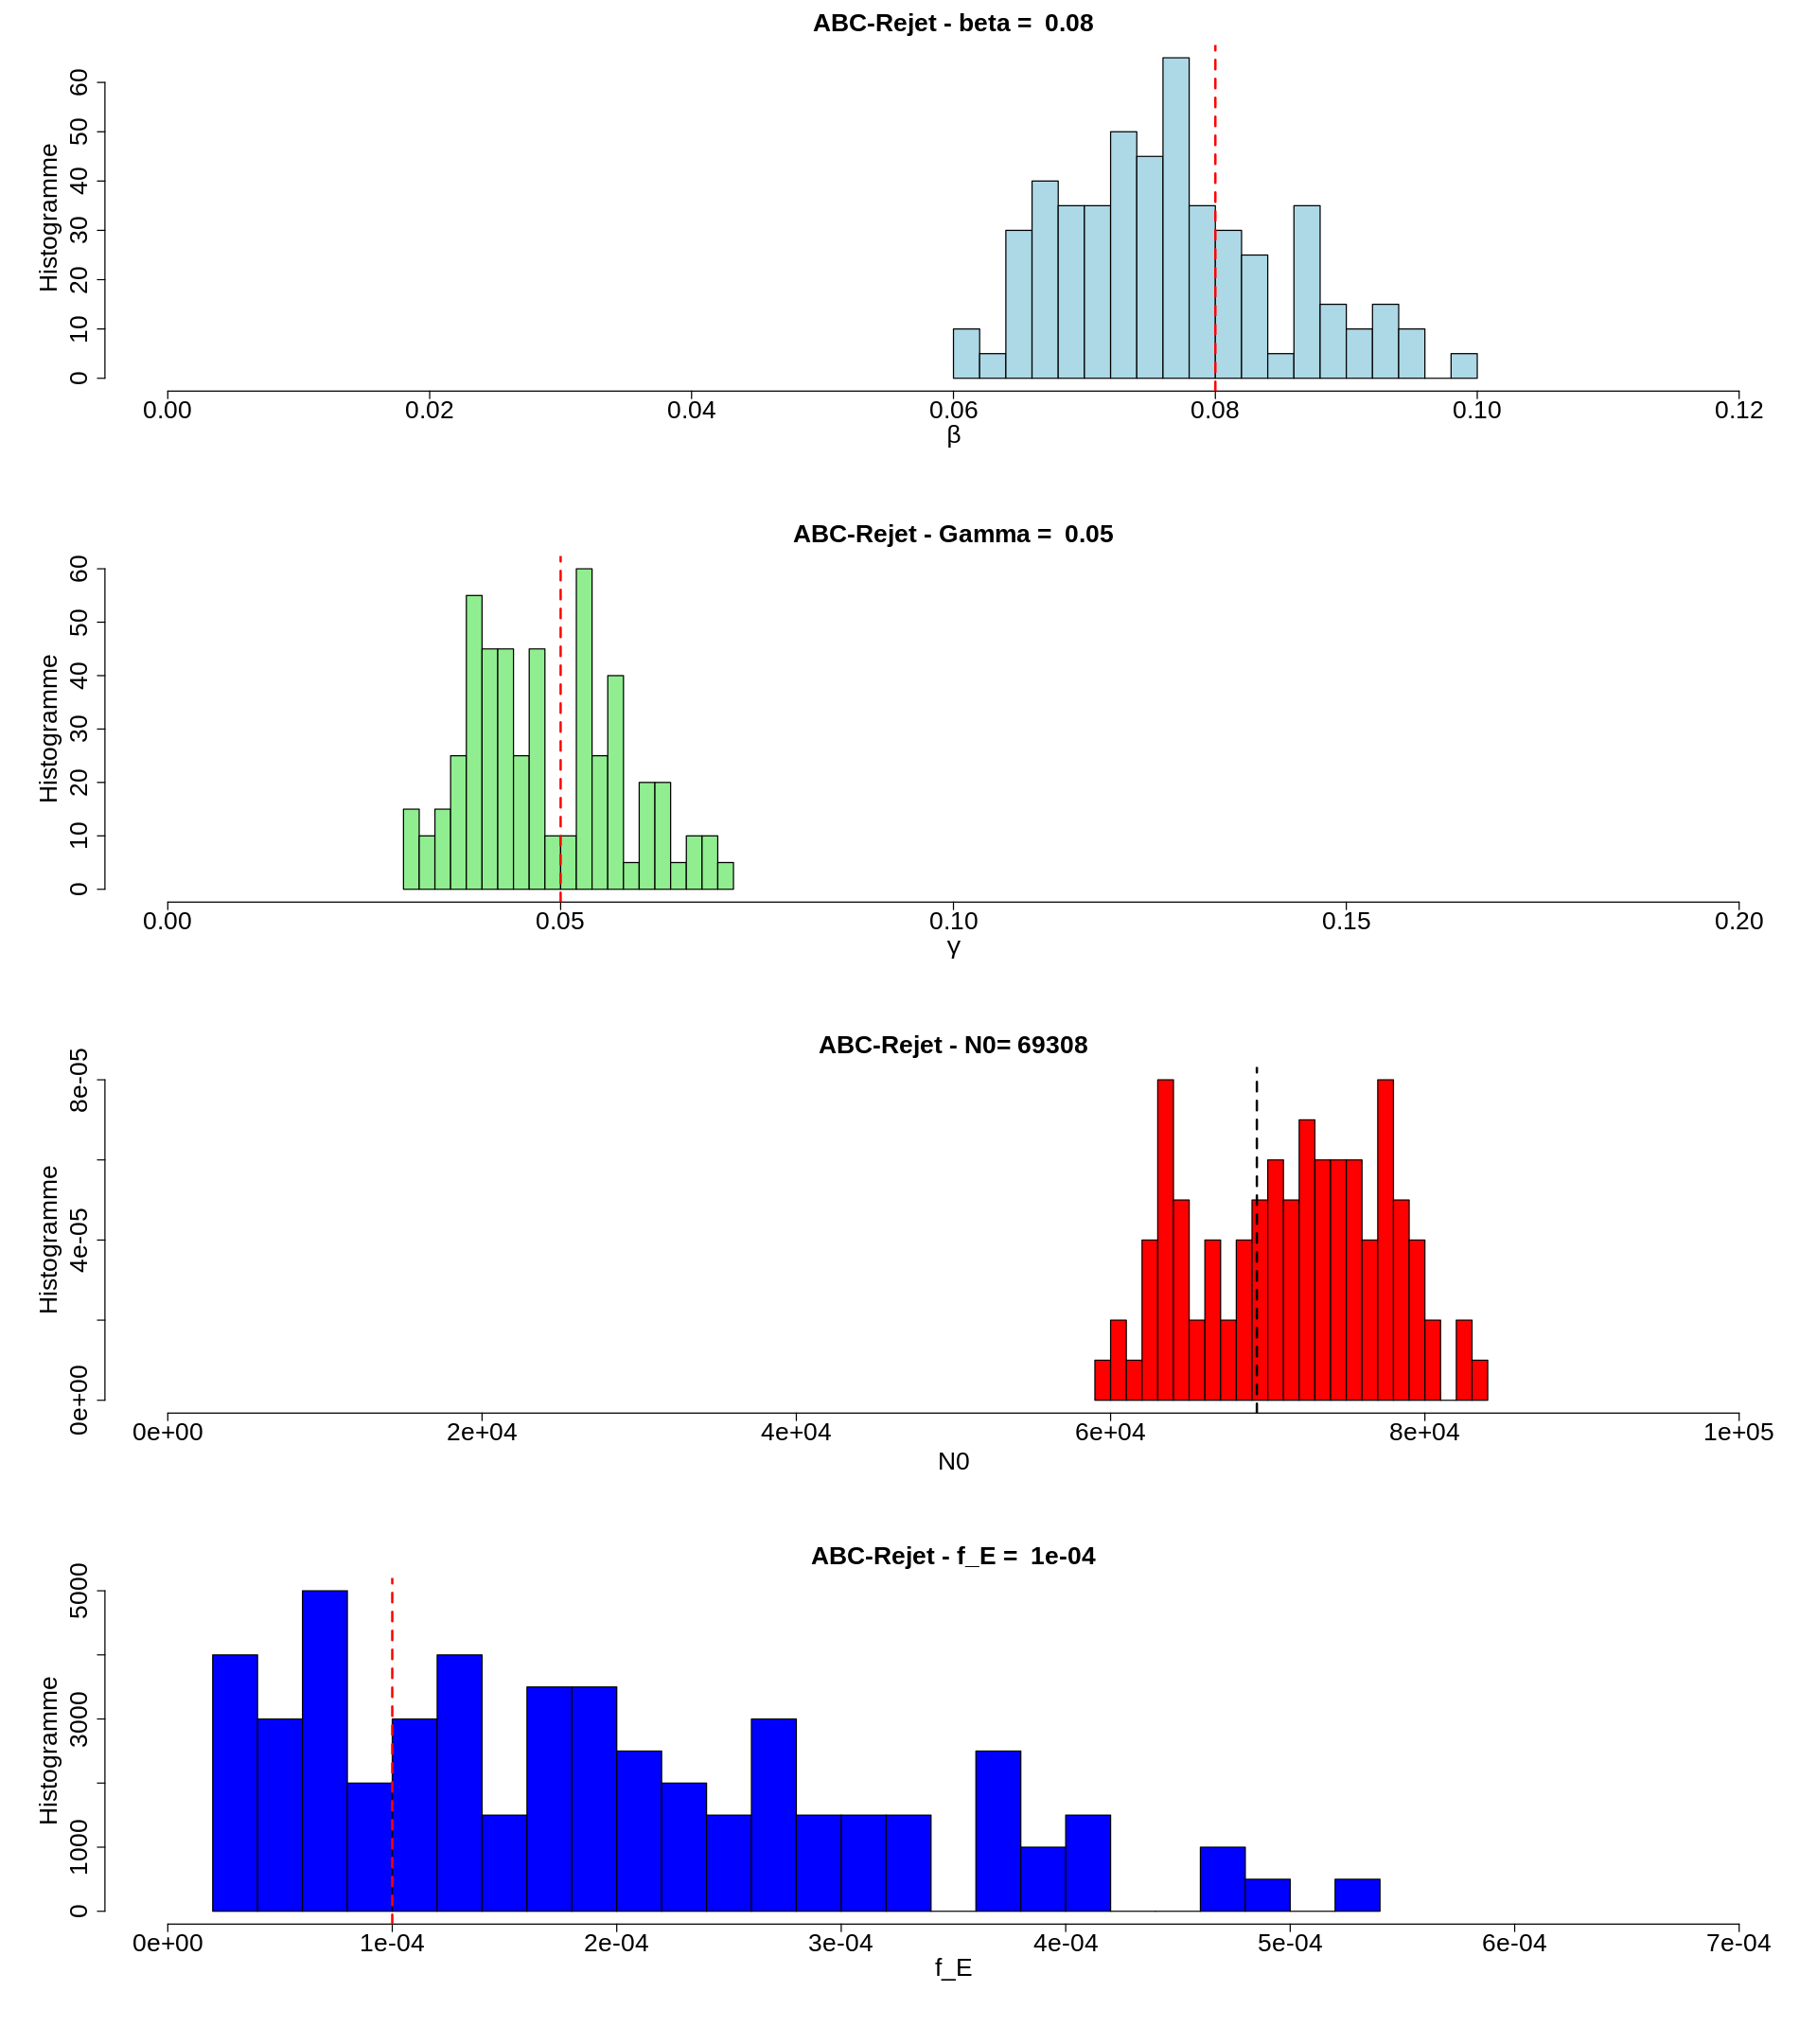

In [ ]:
 #Histogramme des différents paramètres
 #ici res = all_lists

 options(
  repr.plot.width = 16,
  repr.plot.height = 18
)
 par(mfrow = c(4, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes

#Histogramme de Beta
 hist(
    res$beta_star,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("ABC-Rejet","-" ,"beta = " , 0.08),
    xlab = expression(beta),
    xlim = c(0,0.12),
    ylab = "Histogramme",
    cex.main = 2,
    cex.axis = 2 ,

    cex.lab = 2
  )

  abline(
    v = 0.08,
    col = "red",
    lwd = 2,
    lty = 2
  )


  # HISTOGRAMME GAMMA


  hist(
    res$gamma_star,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste("ABC-Rejet","-" ,"Gamma = " , 0.05),
    xlab = expression(gamma),
    xlim = c(0,0.2),
    ylab = "Histogramme",
    cex.main = 2,
    cex.axis = 2 ,
    cex.lab = 2
  )

  abline(
    v = 0.05,
    col = "red",
    lwd = 2,
    lty = 2
  )


  # Histograme de N0

    hist(
    res$N0_total,
    breaks = 20,
    probability = TRUE,
    col = "red",
    main = paste("ABC-Rejet","-" ,"N0=",69308),
    xlab = expression(N0),
    ylab = "Histogramme",
    xlim = c(0 , 100000),
    cex.main = 2,
    cex.axis = 2 ,
    cex.lab = 2
  )

  abline(
    v = 69308,
    col = "black",
    lwd = 2,
    lty = 2
  )

  #Histograme de FE
  hist(
    res$f_E_star,
    breaks = 20,
    probability = TRUE,
    col = "blue",
    main = paste("ABC-Rejet","-" ,"f_E = ", FE),
    xlab = expression(f_E),
    ylab = "Histogramme",
    xlim = c(0 , 0.0007),
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2
  )

  abline(
    v = 0.0001,
    col = "red",
    lwd = 2,
    lty = 2
  )


##**Analyse des paramètres acceptés**

Nous allons analyser les M = 100 particules . Les valeurs théoriques des paramètres sont β = 0.08, γ = 0.05, FE = 0.0001 et N0 = 69308


In [ ]:
estimated_beta = res$beta_star
estimated_gamma = res$gamma_star
estimated_Fe = res$f_E_star
estimated_N0 = res$N0_total

mean_beta = mean(estimated_beta)
mean_gamma = mean(estimated_gamma)
mean_Fe = mean(estimated_Fe)
mean_N0 = mean(estimated_N0)

interv_credible_beta = quantile(estimated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta
interv_credible_gamma = quantile(estimated_gamma, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de gamma
interv_credible_Fe = quantile(estimated_Fe, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de Fe
interv_credible_N0 = quantile(estimated_N0, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de N0

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_beta), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 4), ", ", round(interv_credible_beta[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 4) - round(interv_credible_beta[1], 4), "\n")


cat("Pour le paramètre gamma :\n")
cat("  Moyenne des estimations :", round(mean_gamma, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_gamma), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_gamma[1], 4), ", ", round(interv_credible_gamma[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_gamma[2], 4) - round(interv_credible_gamma[1], 4), "\n\n")

cat("Pour le paramètre Fe :\n")
cat("  Moyenne des estimations :", round(mean_Fe, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_Fe), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_Fe[1], 4), ", ", round(interv_credible_Fe[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_Fe[2], 4) - round(interv_credible_Fe[1], 4), "\n\n")

cat("Pour le paramètre N0 :\n")
cat("  Moyenne des estimations :", round(mean_N0, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_N0), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_N0[1], 4), ", ", round(interv_credible_N0[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_N0[2], 4) - round(interv_credible_N0[1], 4), "\n\n")

Pour le paramètre beta :
  Moyenne des estimations : 0.0766 
  Variance des estimations : 1e-04 
  Intervalle de crédibilité à 95% : [ 0.0637 ,  0.0942 ]
  Largeur de l'intervalle :  0.0305 
Pour le paramètre gamma :
  Moyenne des estimations : 0.0481 
  Variance des estimations : 1e-04 
  Intervalle de crédibilité à 95% : [ 0.032 ,  0.0685 ]
  Largeur de l'intervalle :  0.0365 

Pour le paramètre Fe :
  Moyenne des estimations : 2e-04 
  Variance des estimations : 1.5e-08 
  Intervalle de crédibilité à 95% : [ 0 ,  5e-04 ]
  Largeur de l'intervalle :  5e-04 

Pour le paramètre N0 :
  Moyenne des estimations : 71471.42 
  Variance des estimations : 34475977 
  Intervalle de crédibilité à 95% : [ 61345.62 ,  81539.69 ]
  Largeur de l'intervalle :  20194.07 



In [ ]:
# installation du package nécessaire pour utiliser ABC-SMC
install.packages("tmvtnorm")
library(tmvtnorm)

In [ ]:
# 3 fonctions utilisées dans l'ABC-SMC

rK <- function(mean, sigma){
	return(rtmvnorm(1,mean=mean, sigma=sigma, lower=lm.low, upper=lm.upp))
}

H <- function(x) as.numeric(x>=0)

prior.non.zero<-function(par){
	prod(sapply(1:4, function(a) H(par[a]-lm.low[a])* H(lm.upp[a]-par[a])))
}

**Simulation de ABC-SMC et sauvegarde des informations dans un fichier qui conserve la structure avec save()**

In [ ]:
N <- 1000

# Valeur epsilon pour le nb de nouveau cas par semaine
epsilon_T <- c(
  12000,
  11000,
  10000,
  9000,
  8000,
  7000,
  6000,
  5000,
  4000,
  3000
)

# valeur epsilon pour la proportion de persone malade dans chaque groupe
epsilon_A <- c(0.15,
  0.12,
  0.10,
  0.08,
  0.06,
  0.05,
  0.04,
  0.03,
  0.025,
  0.02)

# Nombre de génération
G <- length(epsilon_T)


# Nombre de simulations pour chaque ensemble de paramètres
n <- 1

#  Les valeurs min et max des distributions uniformes (prior)
lm.low<-c(50000, 0.01, 0.01, 0)
lm.upp<-c(150000, 0.2, 0.2, 0.001)


# Matrice vide pour garder les résultats (5 paramètres)
res.old<-matrix(ncol=4,nrow=N)
res.new<-matrix(ncol=4,nrow=N)

# Matrice vide pour garder le vecteur contenat le poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

for(g in 1:G){

    #Initialisation du compteur
    i<-1
    while(i <= N){    # tant que le nb de particules acceptées est inférieur à N
        if(g==1){
            # Distibutions a priori
            N0_total <- runif(1, min=lm.low[1], max=lm.upp[1])
            prop_age <- c(0.2814265,0.2135655,0.3607184,0.1442896)
            N0_star <- round(N0_total * prop_age)
            gamma_star <-runif(1, min=lm.low[2], max=lm.upp[2])
            beta_star<- runif(1, min=lm.low[3], max=lm.upp[3])
            f_E_star<-runif(1, min=lm.low[4], max=lm.upp[4])
        } else {
            #  Séléction des particules de la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            N0_total<-par[1]
            gamma_star <- par[2]
            beta_star<-par[3]
            f_E_star<-par[4]
        }
        #  test du prior non nul
        if(prior.non.zero(c(N0_total,gamma_star,beta_star,f_E_star))) {
                # Set number of accepted simulations to zero
                m<-0
                distance <-matrix(ncol=2,nrow=n)
                N0_star <- round( N0_total * prop_age )

                for(j in 1:n){
                    D_star<-simuler_age( beta_star, gamma_star , f_E_star,  N0_star)
                    # Calcul des distances
                    calc.dist<-calc_distance(D, D_star)
                    distance[j,] <-calc.dist
                    if((calc.dist[1] <= epsilon_T[g]) & (calc.dist[2] <= epsilon_A[g])){ # Si les deux distances sont inférieures au tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # on saucegarde les résultats dans la matrice
                    res.new[i,]<-c(N0_total,gamma_star, beta_star, f_E_star)
                # Calcul du poids
                w1<-prod(sapply(1:4, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                # Initialisation du compteur
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }
        save(
  g,
  res.new,
  w.new,
  res.old,
  w.old,
  sigma,
  file = paste0(
    "ABC_SMC_gen_",
    g,
    ".RData"
  )
)
        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}

load("ABC_SMC_gen_10.RData") permet de charger les variables se trouvant dans le fichier que l'on doit importer au préalable (Il se trouve dans le Github).

In [ ]:
load("ABC_SMC_gen_10.RData")

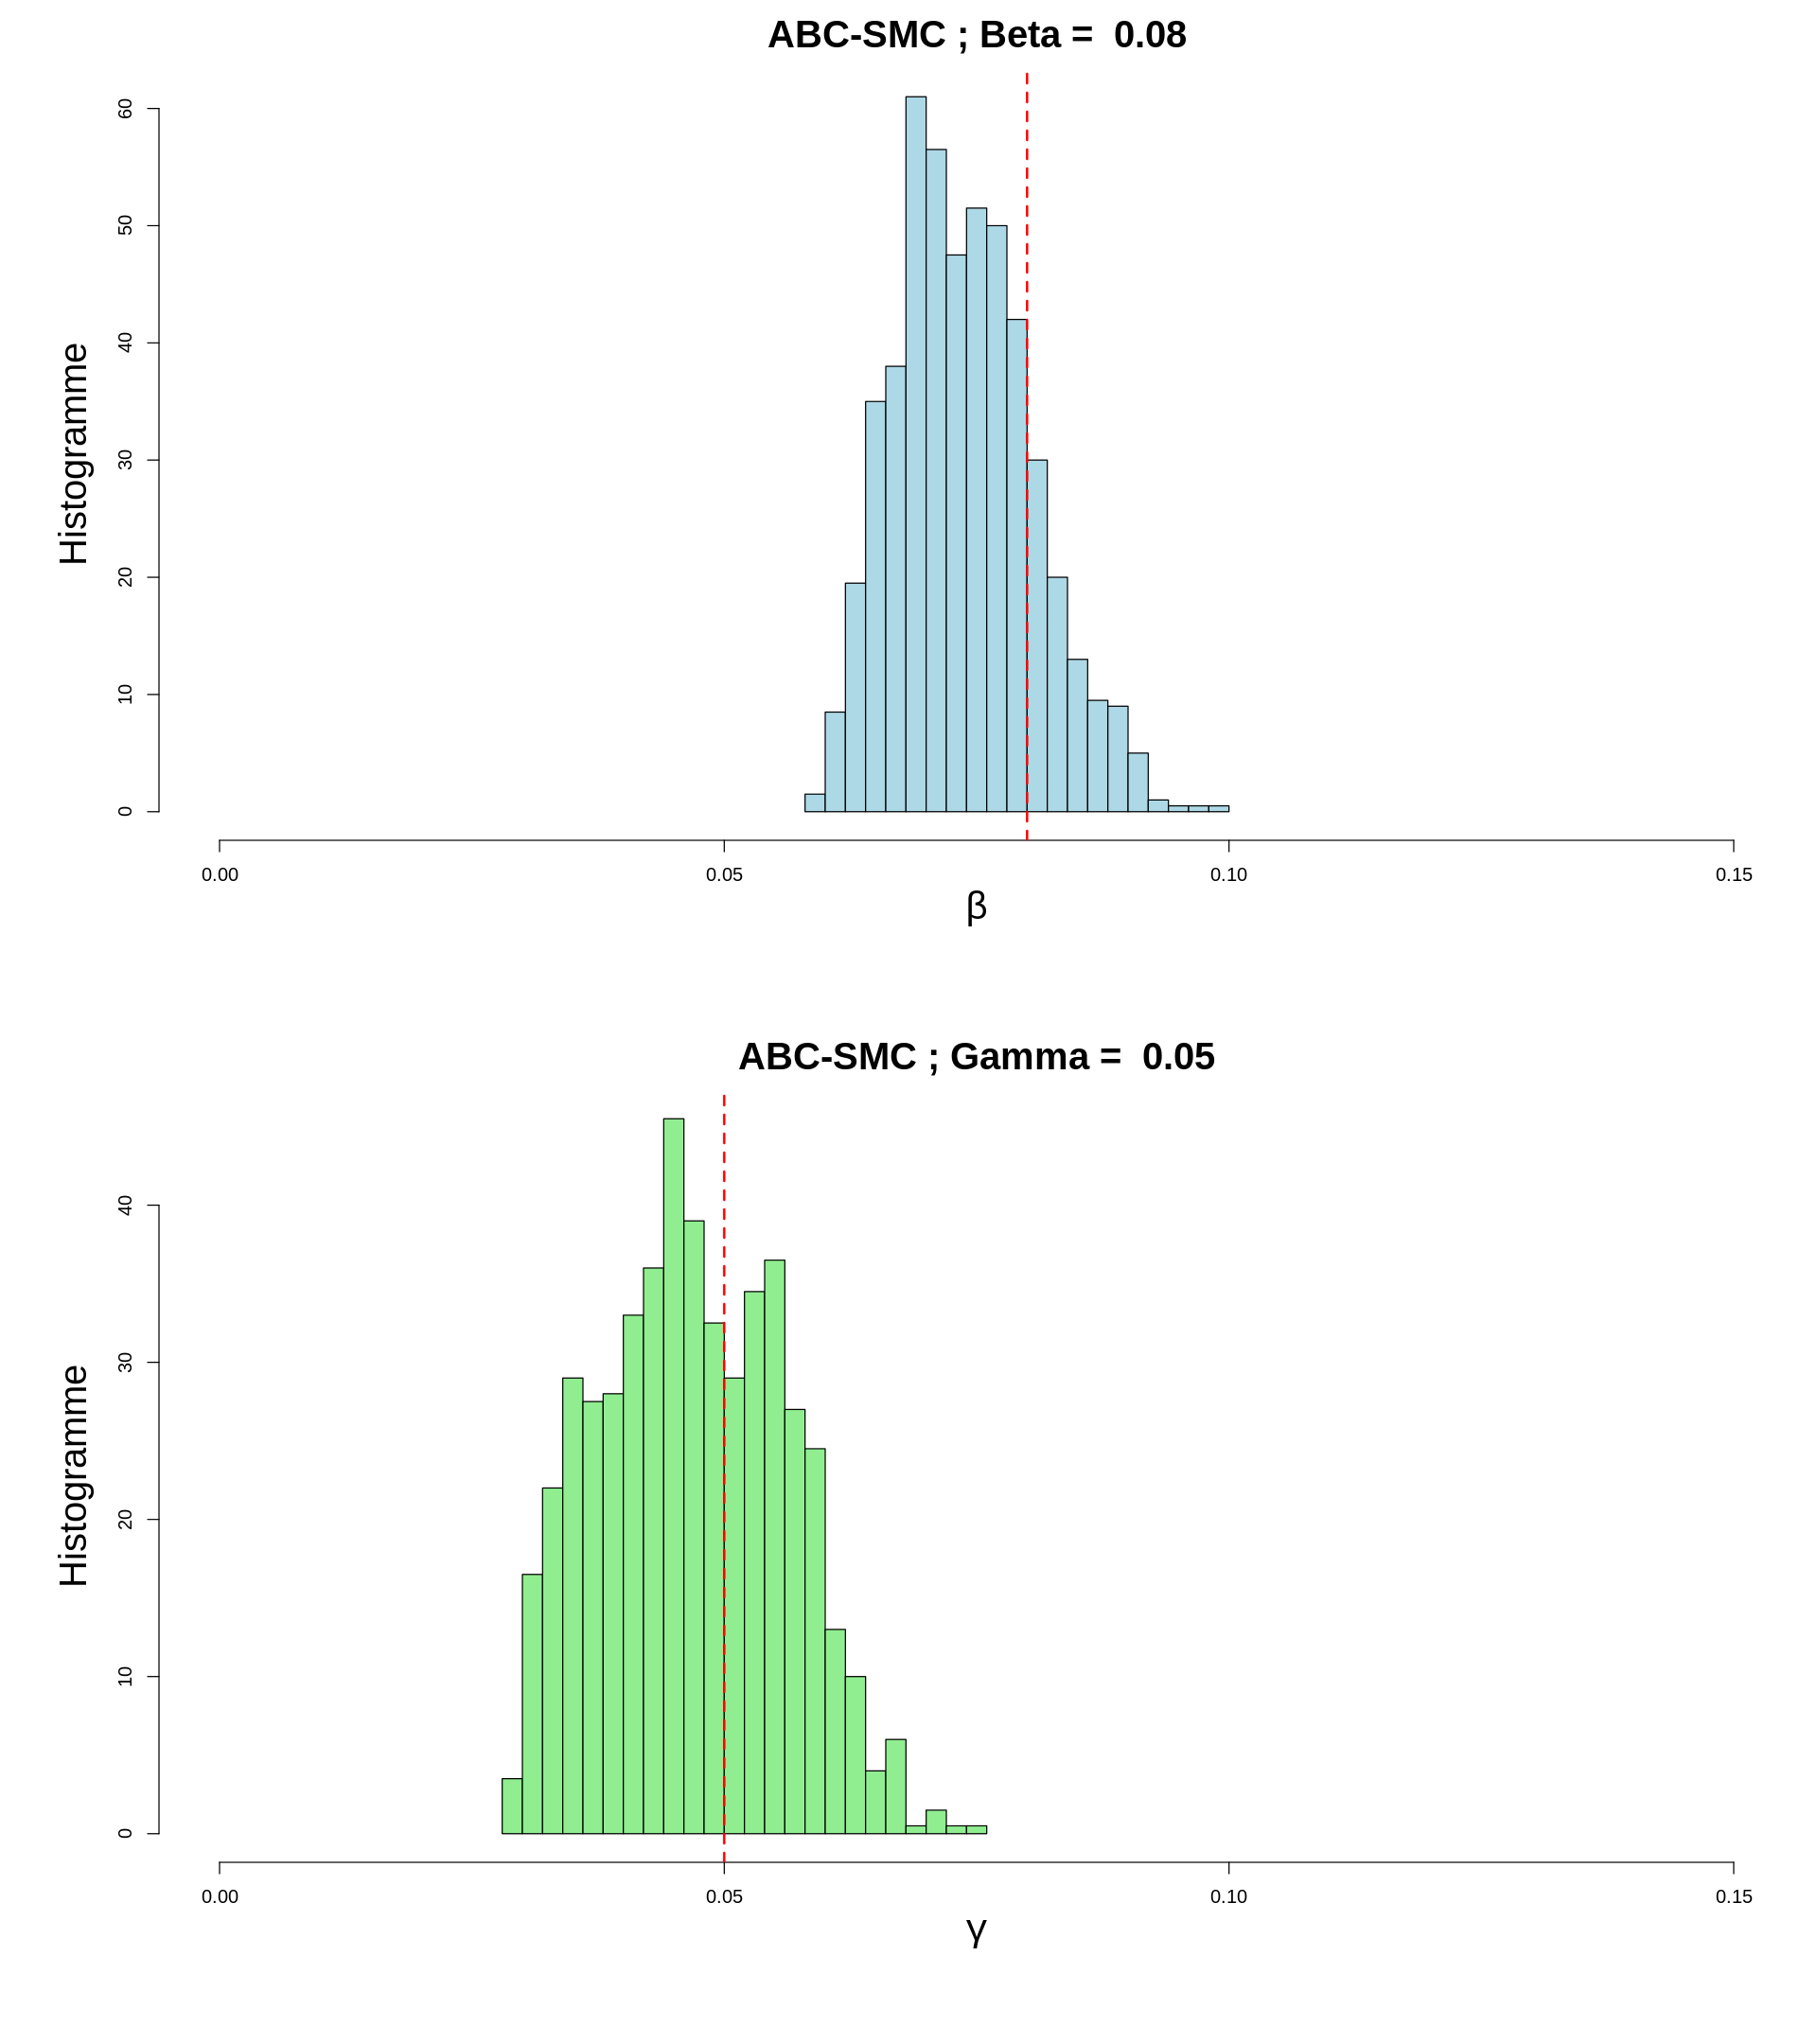

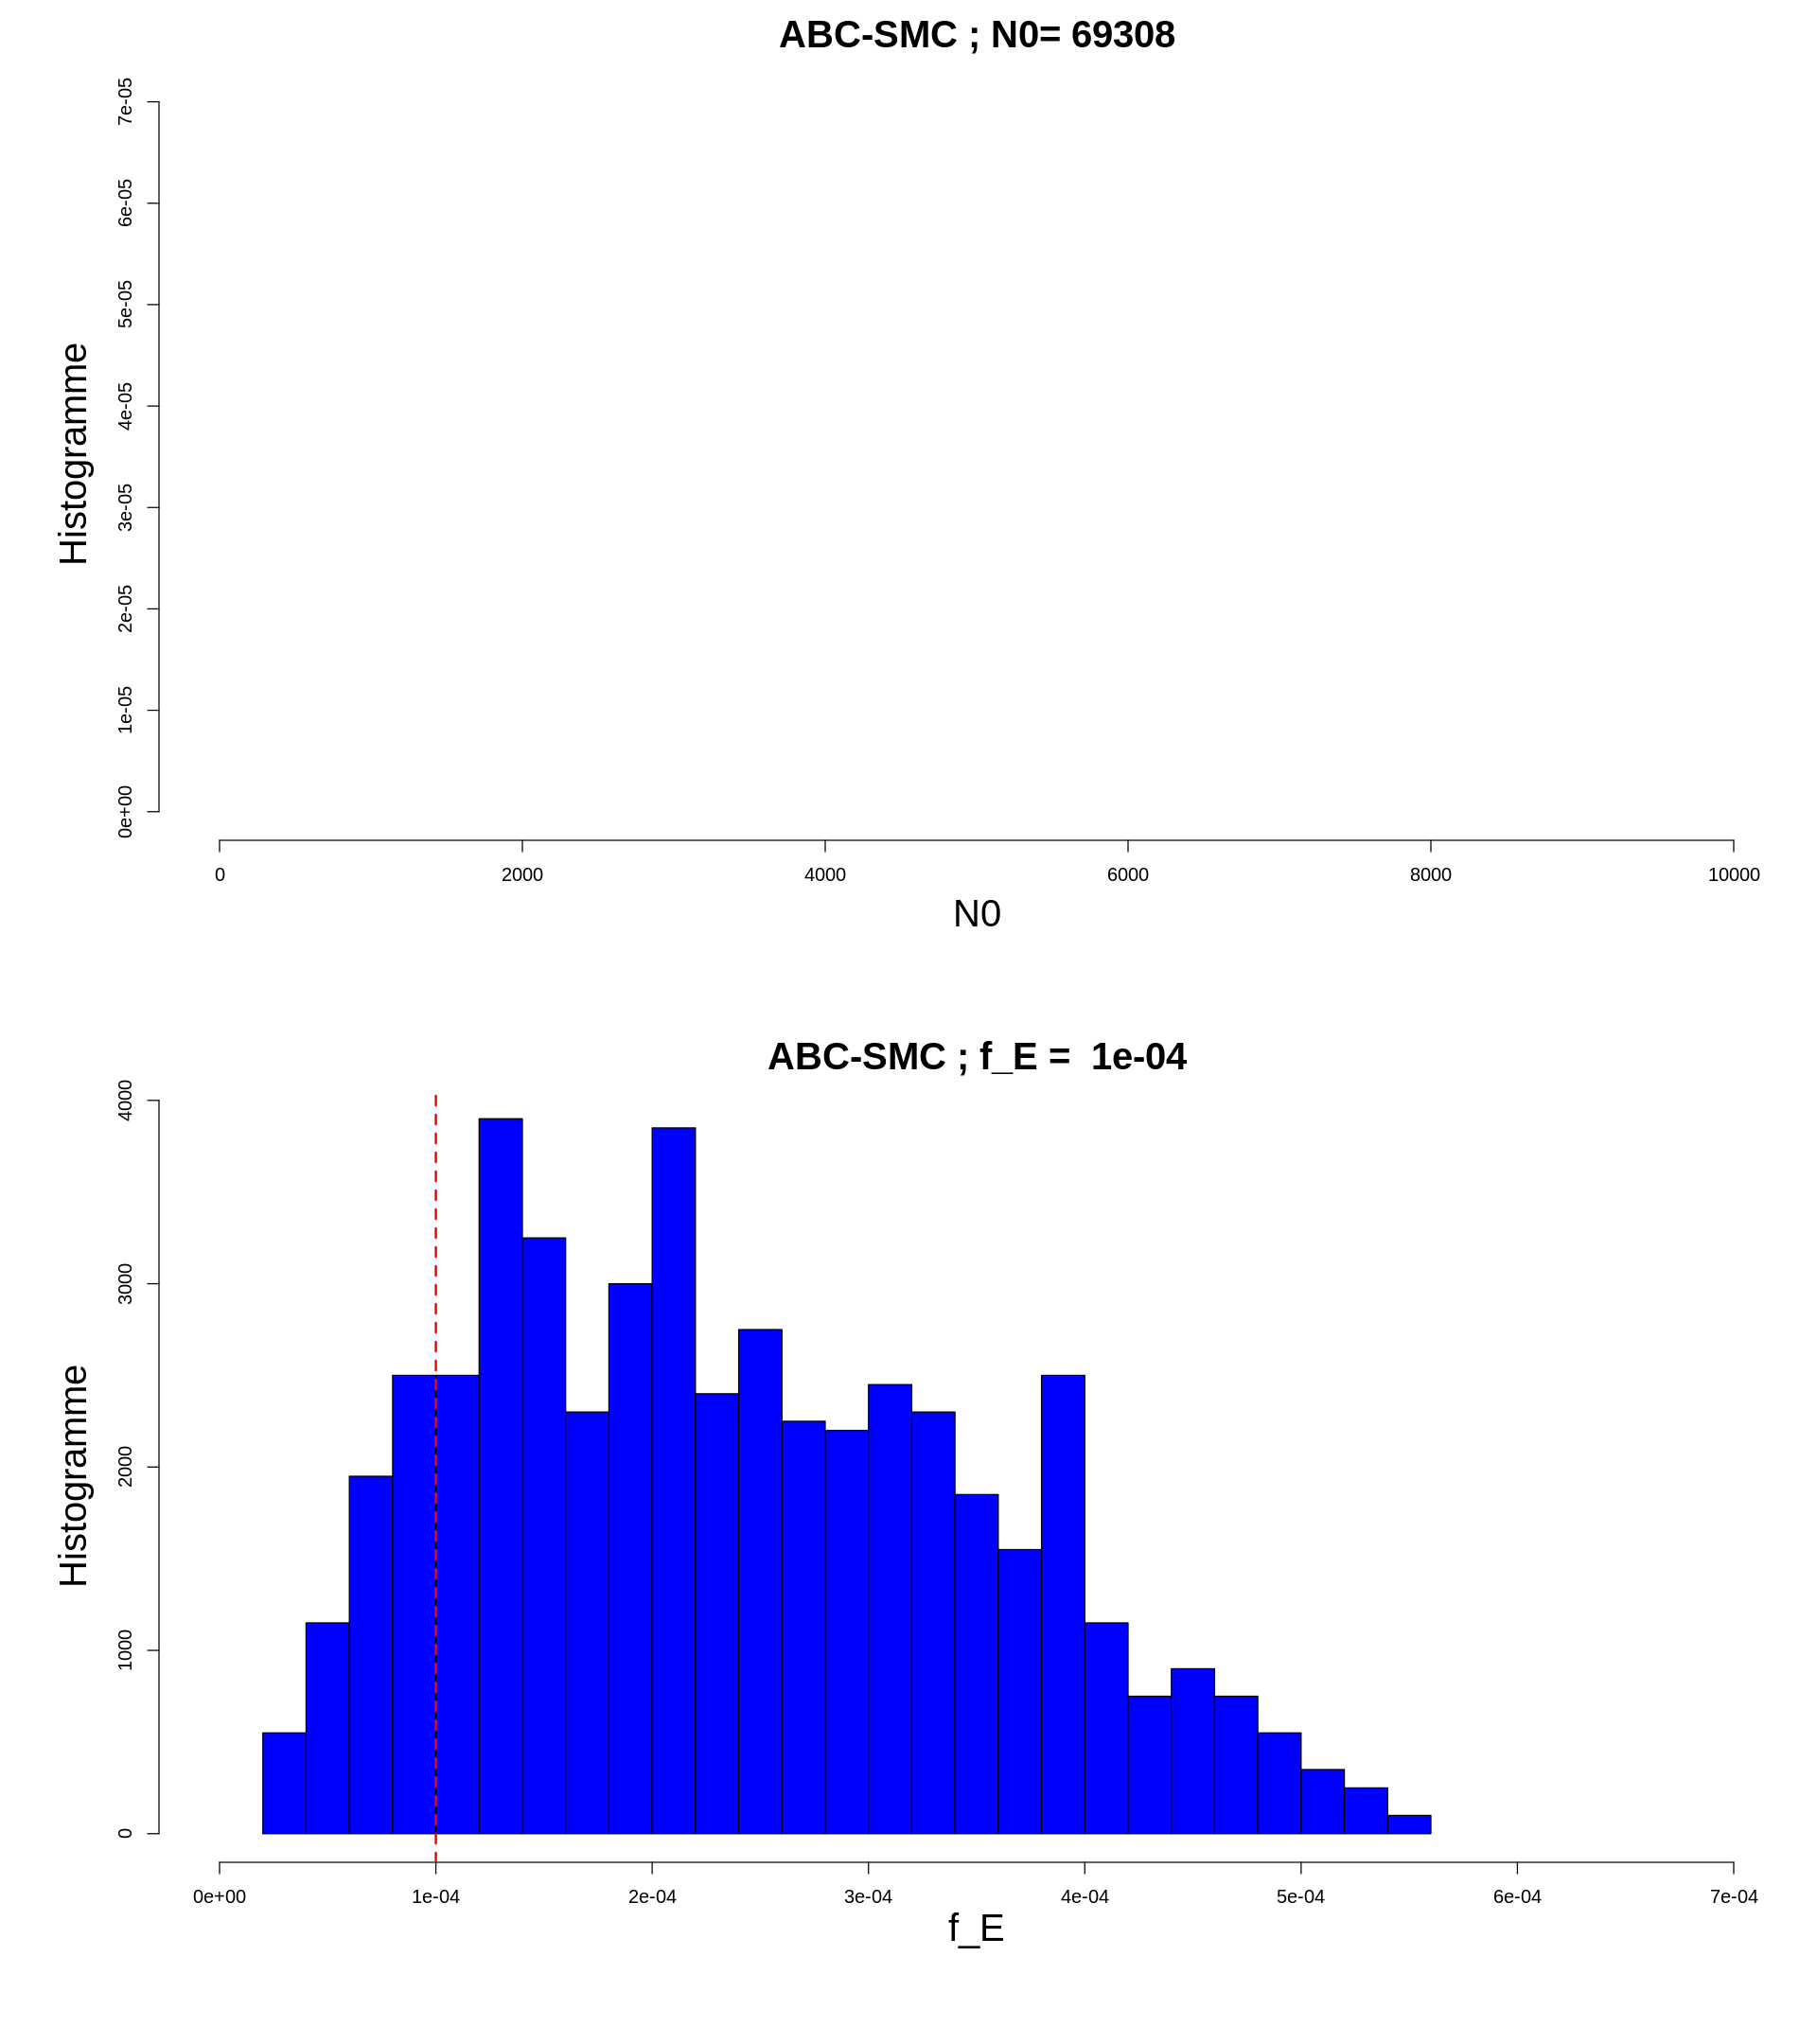

In [ ]:
 # Affichage des différents histogrammes

 par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes

# Histogramme de beta
 hist(
    res.new[,3],
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("ABC-SMC",";","Beta = " , 0.08),
    xlab = expression(beta),
    ylab = "Histogramme",
    xlim = c(0,0.15),
    cex.main = 2,
    cex.lab = 2
  )

  abline(
    v = 0.08,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # HISTOGRAMME GAMMA

  hist(
    res.new[,2],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste("ABC-SMC",";","Gamma = " , 0.05),
    ylab = "Histogramme",
    xlab = expression(gamma),
    xlim = c(0,0.15),
    cex.main = 2,
    cex.lab = 2
  )

  abline(
    v = 0.05,
    col = "red",
    lwd = 2,
    lty = 2
  )


  #Histograme de N0

    hist(
    res.new[,1],
    breaks = 20,
    probability = TRUE,
    col = "red",
    main = paste("ABC-SMC",";","N0=",69308),
    xlab = expression(N0),
    xlim = c(0,10000),

    ylab = "Histogramme",
    cex.main = 2,
    cex.lab = 2
  )

  abline(
    v = 69308,
    col = "black",
    lwd = 2,
    lty = 2
  )

  #Histograme de FE
  hist(
    res.new[,4],
    breaks = 20,
    probability = TRUE,
    col = "blue",
    main = paste("ABC-SMC",";","f_E = ",FE),
    xlab = expression(f_E),
    xlim = c(0 , 7e-4),
    ylab = "Histogramme",
    cex.main = 2,
    cex.lab = 2
  )

  abline(
    v = 0.0001,
    col = "red",
    lwd = 2,
    lty = 2
  )

##**Analyse des paramètres acceptés**
Nous allons utiliser les 3 cas avec N le nombre de particule égale à 1000.
Les valeurs théoriques des paramètres sont β = 0.08 et γ = 0.05.

In [ ]:
estimated_beta = res.new[,3]
estimated_gamma = res.new[,2]
estimated_Fe = res.new[,4]
estimated_N0 = res.new[,1]

mean_beta = mean(estimated_beta)
mean_gamma = mean(estimated_gamma)
mean_Fe = mean(estimated_Fe)
mean_N0 = mean(estimated_N0)

interv_credible_beta = quantile(estimated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta
interv_credible_gamma = quantile(estimated_gamma, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de gamma
interv_credible_Fe = quantile(estimated_Fe, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de Fe
interv_credible_N0 = quantile(estimated_N0, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de N0

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_beta), 6), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 4), ", ", round(interv_credible_beta[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 4) - round(interv_credible_beta[1], 4), "\n\n")



cat("Pour le paramètre gamma :\n")
cat("  Moyenne des estimations :", round(mean_gamma, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_gamma), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_gamma[1], 4), ", ", round(interv_credible_gamma[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_gamma[2], 4) - round(interv_credible_gamma[1], 4), "\n\n")

cat("Pour le paramètre Fe :\n")
cat("  Moyenne des estimations :", round(mean_Fe, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_Fe), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_Fe[1], 4), ", ", round(interv_credible_Fe[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_Fe[2], 4) - round(interv_credible_Fe[1], 4), "\n\n")

cat("Pour le paramètre N0 :\n")
cat("  Moyenne des estimations :", round(mean_N0, 4), "\n")
cat("  Variance des estimations :", round(var(estimated_N0), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_N0[1], 4), ", ", round(interv_credible_N0[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_N0[2], 4) - round(interv_credible_N0[1], 4), "\n\n")


Pour le paramètre beta :
  Moyenne des estimations : 0.0738 
  Variance des estimations : 4.7e-05 
  Intervalle de crédibilité à 95% : [ 0.0622 ,  0.0886 ]
  Largeur de l'intervalle :  0.0264 

Pour le paramètre gamma :
  Moyenne des estimations : 0.0469 
  Variance des estimations : 1e-04 
  Intervalle de crédibilité à 95% : [ 0.0311 ,  0.0647 ]
  Largeur de l'intervalle :  0.0336 

Pour le paramètre Fe :
  Moyenne des estimations : 2e-04 
  Variance des estimations : 0 
  Intervalle de crédibilité à 95% : [ 1e-04 ,  5e-04 ]
  Largeur de l'intervalle :  4e-04 

Pour le paramètre N0 :
  Moyenne des estimations : 72239.96 
  Variance des estimations : 29525112 
  Intervalle de crédibilité à 95% : [ 61854.36 ,  82507.96 ]
  Largeur de l'intervalle :  20653.6 

